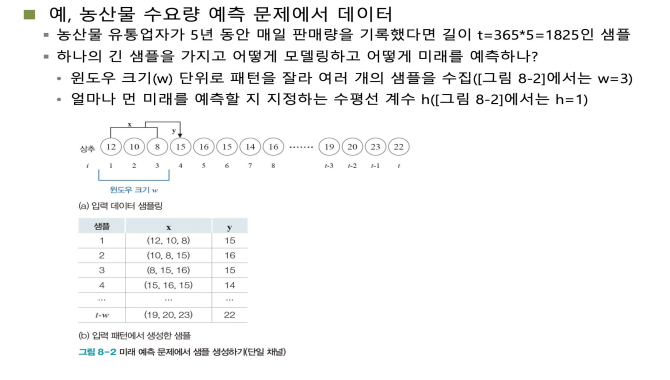

In [15]:
# 1. 시계열 데이터를 준비
import numpy as np
import pandas as pd

# 시계열 (슬라이드에 있던 값)
series = np.array([12, 10, 8, 15, 16, 15, 14, 16, 19, 20, 23, 22])

# 2. 원도우와 수평선 계수를 이용해 x,y 샘플 만들기
def make_dataset(series, window_size=3, horizon=1):
    X = []  # 입력 패턴들 (x)
    y = []  # 타깃값들   (y)

    # i에서 시작해 window_size개를 x, 그 뒤 horizon번째 값을 y로 사용
    for i in range(len(series) - window_size - horizon + 1):
        x_i = series[i : i + window_size]                 # 예: [12, 10, 8]
        y_i = series[i + window_size + horizon - 1]       # 예: 15
        X.append(x_i)
        y.append(y_i)

    data = {'X': X, 'Y':y}
    df = pd.DataFrame(data)
    return df

df = make_dataset(series, window_size=3, horizon=1)
df

,X,Y
0,"[12, 10, 8]",15
1,"[10, 8, 15]",16
2,"[8, 15, 16]",15
3,"[15, 16, 15]",14
4,"[16, 15, 14]",16
5,"[15, 14, 16]",19
6,"[14, 16, 19]",20
7,"[16, 19, 20]",23
8,"[19, 20, 23]",22


In [16]:
df = make_dataset(series, window_size=4, horizon=2)
df

,X,Y
0,"[12, 10, 8, 15]",15
1,"[10, 8, 15, 16]",14
2,"[8, 15, 16, 15]",16
3,"[15, 16, 15, 14]",19
4,"[16, 15, 14, 16]",20
5,"[15, 14, 16, 19]",23
6,"[14, 16, 19, 20]",22


### RNN 실습해보기

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
import tensorflow as tf

tf.keras.utils.set_random_seed(42)
tf.config.experimental.enable_op_determinism()

In [54]:
from tensorflow.keras.datasets import imdb

(train_input, train_target), (test_input, test_target) = imdb.load_data(num_words = 500)

In [55]:
train_input.shape, test_input.shape

((25000,), (25000,))

In [56]:
train_target.shape, test_target.shape

((25000,), (25000,))

In [57]:
len(train_input[0])

218

In [58]:
print(train_input[0])
print(train_input[1])

[1, 14, 22, 16, 43, 2, 2, 2, 2, 65, 458, 2, 66, 2, 4, 173, 36, 256, 5, 25, 100, 43, 2, 112, 50, 2, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 2, 2, 17, 2, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2, 19, 14, 22, 4, 2, 2, 469, 4, 22, 71, 87, 12, 16, 43, 2, 38, 76, 15, 13, 2, 4, 22, 17, 2, 17, 12, 16, 2, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2, 2, 16, 480, 66, 2, 33, 4, 130, 12, 16, 38, 2, 5, 25, 124, 51, 36, 135, 48, 25, 2, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 2, 15, 256, 4, 2, 7, 2, 5, 2, 36, 71, 43, 2, 476, 26, 400, 317, 46, 7, 4, 2, 2, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2, 56, 26, 141, 6, 194, 2, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 2, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 2, 88, 12, 16, 283, 5, 16, 2, 113, 103, 32, 15, 16, 2, 19, 178, 32]
[1, 194, 2, 194, 2, 78, 228, 5, 6, 2, 2, 2, 134, 26, 4, 2, 8, 118, 2, 14, 394, 20, 13, 119, 2, 189, 102, 5, 207, 110, 2, 21, 14, 69, 188, 8, 30, 23, 7,

In [59]:
print(train_target[:10])
# positive = 1
# negative = 0
print(np.unique(train_target, return_counts= True))

[1 0 0 1 0 0 1 0 1 0]
(array([0, 1], dtype=int64), array([12500, 12500], dtype=int64))


In [60]:
# 단어 인덱스 번호 가져오기
word_index = imdb.get_word_index()
reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()]
)
decoded_review =''.join(
    [reverse_word_index.get(i-3,"?")for i in train_input[0]]
)
print(decoded_review)

?thisfilmwasjust????storydirection?really?theparttheyplayedandyoucouldjust?beingthere??isanamazingactorandnowthesamebeingdirector?fathercamefromthesame??as?soilovedthefacttherewasareal?withthisfilmthe??throughoutthefilmweregreatitwasjust?somuchthati?thefilmas?asitwas?for?andwouldrecommendittoeveryonetowatchandthe??wasamazingreally?attheenditwasso?andyouknowwhattheysayifyou?atafilmitmusthavebeengoodandthisdefinitelywasalso?tothetwolittle?thatplayedthe?of?and?theywerejust?childrenareoftenleftoutofthe??ithinkbecausethestarsthatplaythemall?uparesuchabig?forthewholefilmbutthesechildrenareamazingandshouldbe?forwhattheyhavedonedon'tyouthinkthewholestorywasso?becauseitwastrueandwas?lifeafterallthatwas?withusall


In [61]:
from sklearn.model_selection import train_test_split

train_input, val_input, train_target, val_target = train_test_split(
    train_input, train_target, test_size = 0.2, random_state=42
)

In [62]:
train_input.shape, train_target.shape, val_input.shape, val_target.shape

((20000,), (20000,), (5000,), (5000,))

239.00925 178.0


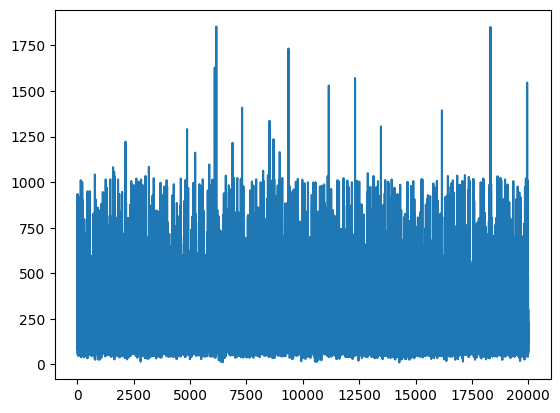

In [63]:
lengths = np.array([len(x) for x in train_input])

print(np.mean(lengths), np.median(lengths))
plt.plot(lengths)
plt.show()

In [64]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [65]:
# 각 리뷰를 100자 기준으로 잘라낸거
train_seq = pad_sequences(train_input, maxlen=100)

In [66]:
train_seq.shape

(20000, 100)

In [67]:
train_seq[0]

array([ 10,   4,  20,   9,   2, 364, 352,   5,  45,   6,   2,   2,  33,
       269,   8,   2, 142,   2,   5,   2,  17,  73,  17, 204,   5,   2,
        19,  55,   2,   2,  92,  66, 104,  14,  20,  93,  76,   2, 151,
        33,   4,  58,  12, 188,   2, 151,  12, 215,  69, 224, 142,  73,
       237,   6,   2,   7,   2,   2, 188,   2, 103,  14,  31,  10,  10,
       451,   7,   2,   5,   2,  80,  91,   2,  30,   2,  34,  14,  20,
       151,  50,  26, 131,  49,   2,  84,  46,  50,  37,  80,  79,   6,
         2,  46,   7,  14,  20,  10,  10, 470, 158])

In [68]:
print(train_input[0][-100:])

[10, 4, 20, 9, 2, 364, 352, 5, 45, 6, 2, 2, 33, 269, 8, 2, 142, 2, 5, 2, 17, 73, 17, 204, 5, 2, 19, 55, 2, 2, 92, 66, 104, 14, 20, 93, 76, 2, 151, 33, 4, 58, 12, 188, 2, 151, 12, 215, 69, 224, 142, 73, 237, 6, 2, 7, 2, 2, 188, 2, 103, 14, 31, 10, 10, 451, 7, 2, 5, 2, 80, 91, 2, 30, 2, 34, 14, 20, 151, 50, 26, 131, 49, 2, 84, 46, 50, 37, 80, 79, 6, 2, 46, 7, 14, 20, 10, 10, 470, 158]


In [69]:
val_seq = pad_sequences(val_input, maxlen=100)

In [70]:
val_seq.shape

(5000, 100)

In [71]:
from tensorflow import keras

train_oh = keras.utils.to_categorical(train_seq)
val_oh = keras.utils.to_categorical(val_seq)

In [72]:
from tensorflow import keras

model = keras.Sequential()

model.add(keras.layers.SimpleRNN(8, input_shape=(100,500)))
model.add(keras.layers.Dense(1, activation='sigmoid'))

In [73]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 simple_rnn_1 (SimpleRNN)    (None, 8)                 4072      
                                                                 
 dense_1 (Dense)             (None, 1)                 9         
                                                                 
Total params: 4,081
Trainable params: 4,081
Non-trainable params: 0
_________________________________________________________________


In [74]:
rmsprop = keras.optimizers.RMSprop(learning_rate=1e-4)
model.compile(optimizer = rmsprop, loss = 'binary_crossentropy', metrics = ['accuracy'])

checkpoint_cb = keras.callbacks.ModelCheckpoint('output/best_simplearnn_model.keras', save_best_only=True)
early_stopping_cb = keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)

history = model.fit(train_oh, train_target, epochs =100, batch_size=64, 
                    validation_data=[val_oh, val_target],
                    callbacks=[checkpoint_cb, early_stopping_cb])

Epoch 1/100
313/313 [==============================] - 31s 47ms/step - loss: 0.7026 - accuracy: 0.5009 - val_loss: 0.6965 - val_accuracy: 0.5142
Epoch 2/100
313/313 [==============================] - 14s 46ms/step - loss: 0.6926 - accuracy: 0.5246 - val_loss: 0.6887 - val_accuracy: 0.5358
Epoch 3/100
313/313 [==============================] - 14s 46ms/step - loss: 0.6800 - accuracy: 0.5628 - val_loss: 0.6727 - val_accuracy: 0.5902
Epoch 4/100
313/313 [==============================] - 14s 44ms/step - loss: 0.6608 - accuracy: 0.6123 - val_loss: 0.6563 - val_accuracy: 0.6222
Epoch 5/100
313/313 [==============================] - 14s 46ms/step - loss: 0.6437 - accuracy: 0.6479 - val_loss: 0.6394 - val_accuracy: 0.6586
Epoch 6/100
313/313 [==============================] - 14s 43ms/step - loss: 0.6271 - accuracy: 0.6777 - val_loss: 0.6237 - val_accuracy: 0.6834
Epoch 7/100
313/313 [==============================] - 14s 45ms/step - loss: 0.6109 - accuracy: 0.6978 - val_loss: 0.6093 - val_ac

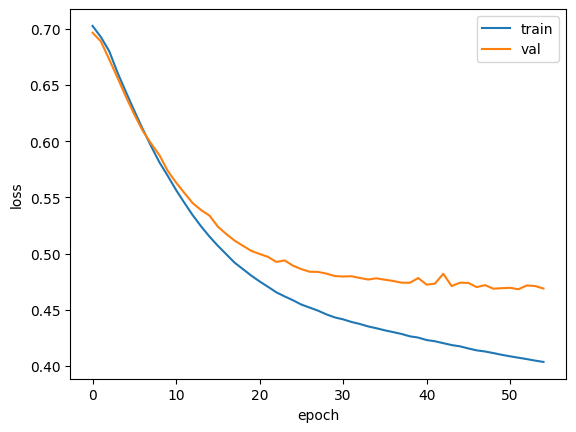

In [75]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'])
plt.show()